# Natural Language Processing

## Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importing the datasets

In [2]:
true_news_data = pd.read_csv('True.csv')
fake_news_data = pd.read_csv('Fake.csv')

In [3]:
true_news_data.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [4]:
fake_news_data.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


## Add traget column in dataset

In [5]:
true_news_data['target'] = 1
fake_news_data['target'] = 0

In [6]:
true_news_data.columns

Index(['title', 'text', 'subject', 'date', 'target'], dtype='object')

In [7]:
fake_news_data.columns

Index(['title', 'text', 'subject', 'date', 'target'], dtype='object')

## Concatenate the both dataset in single dataset

In [8]:
dataset = pd.concat([true_news_data, fake_news_data], ignore_index=True)

In [9]:
dataset.head()

,title,text,subject,date,target
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [10]:
dataset.isna().sum()

title      0
text       0
subject    0
date       0
target     0
dtype: int64

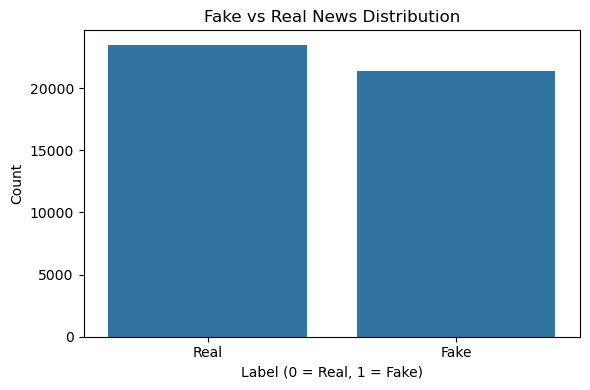

In [11]:

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.countplot(data=dataset, x='target')
plt.title("Fake vs Real News Distribution")
plt.xlabel("Label (0 = Real, 1 = Fake)")
plt.ylabel("Count")
plt.xticks([0, 1], ["Real", "Fake"])
plt.tight_layout()
plt.show()
     

## Drop unusual features

In [12]:
dataset.drop(['subject', 'date'], axis=1, inplace=True)
dataset.head()

,title,text,target
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,1


In [13]:
print("Dataset shape:", dataset.shape)
print(dataset["target"].value_counts())

Dataset shape: (44898, 3)
target
0    23481
1    21417
Name: count, dtype: int64


### Add both varibales in one variable

In [14]:
dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)
print("Dataset shape:", dataset.shape)
print(dataset["target"].value_counts())

Dataset shape: (44898, 3)
target
0    23481
1    21417
Name: count, dtype: int64


## Cleaning the texts

In [15]:
dataset["content"] = dataset["title"] + " " + dataset["text"]
print("\nSample content (first 200 chars):")
print(dataset["content"][0][:200])


Sample content (first 200 chars):
 BREAKING: GOP Chairman Grassley Has Had Enough, DEMANDS Trump Jr. Testimony Donald Trump s White House is in chaos, and they are trying to cover it up. Their Russia problems are mounting by the hour,


In [16]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
def clean_text(text):
    text = text.lower()                                      # Lowercase
    text = re.sub(r'\[.*?\]|\(.*?\)', '', text)              # Remove text in brackets
    text = re.sub(r'https?://\S+|www\.\S+', '', text)        # Remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)                    # Keep only letters
    text = re.sub(r'\s+', ' ', text).strip()                 # Remove extra spaces
    return text

print("\nCleaning text...")

# Fill missing values
dataset["content"] = dataset["content"].fillna("")

# Apply cleaning
dataset["cleaned"] = dataset["content"].apply(clean_text)

# TF-IDF Vectorization
tv = TfidfVectorizer(max_features=5000, stop_words="english")

X = tv.fit_transform(dataset["cleaned"])
y = dataset["target"].values

print("\n✅ TF-IDF Shape:", X.shape)

feature_names = tv.get_feature_names_out()

print("\nSample TF-IDF Features:")
print(feature_names[:20])


Cleaning text...

✅ TF-IDF Shape: (44898, 5000)

Sample TF-IDF Features:
['abadi' 'abandon' 'abandoned' 'abbas' 'abc' 'abdullah' 'abe' 'abedin'
 'ability' 'able' 'abortion' 'abortions' 'abroad' 'absence' 'absolute'
 'absolutely' 'absurd' 'abu' 'abuse' 'abused']


## Creating the Bag of Words model

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
tv = TfidfVectorizer(max_features=5000, stop_words='english')
X = tv.fit_transform(dataset["cleaned"])
y = dataset["target"]

In [18]:
print(X.shape)

(44898, 5000)


## Splitting the dataset into the Training set and Test set

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify = y)

## Training the Best ML model on the Training set

In [20]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Naive Bayes
print("\nTraining Naive Bayes...")
nb = MultinomialNB()
nb.fit(X_train, y_train)

# Random Forest
print("\nTraining Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print("\n✅ All models trained successfully!")

Training Logistic Regression...

Training Naive Bayes...

Training Random Forest...

✅ All models trained successfully!


## Predicting the Test set results

In [21]:
# Logistic Regression Prediction
y_pred_lr = lr.predict(X_test)

# Naive Bayes Prediction
y_pred_nb = nb.predict(X_test)

# Random Forest Prediction
y_pred_rf = rf.predict(X_test)


## Making the Confusion Matrix

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

models = {
    "Logistic Regression": lr,
    "Naive Bayes": nb,
    "Random Forest": rf
}
for name, model in models.items():
    y_pred = model.predict(X_test)

    print(f"\n🔹 {name}")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Fake", "Real"]
    ))
    print("-" * 60)


🔹 Logistic Regression
              precision    recall  f1-score   support

        Fake       0.99      0.98      0.98      4696
        Real       0.97      0.98      0.98      4284

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980

------------------------------------------------------------

🔹 Naive Bayes
              precision    recall  f1-score   support

        Fake       0.92      0.94      0.93      4696
        Real       0.93      0.92      0.92      4284

    accuracy                           0.93      8980
   macro avg       0.93      0.93      0.93      8980
weighted avg       0.93      0.93      0.93      8980

------------------------------------------------------------

🔹 Random Forest
              precision    recall  f1-score   support

        Fake       0.99      0.98      0.98      4696
        Real       0.98      0.99      0.98      4284

    a

In [23]:
results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1 Score": round(f1_score(y_test, y_pred), 4)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9798,0.9741,0.9839,0.9790
1,Naive Bayes,0.9261,0.9281,0.9160,0.9220
2,Random Forest,0.9843,0.9798,0.9874,0.9836


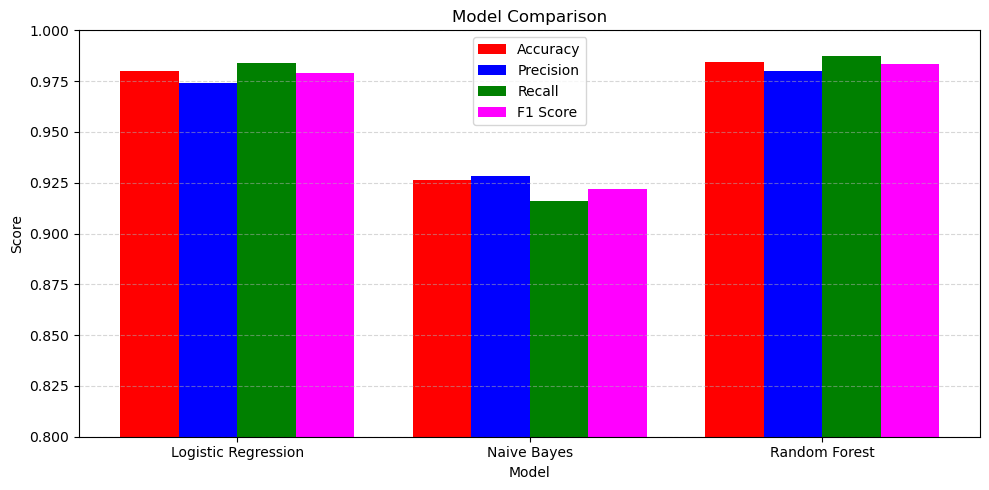

In [24]:
x = np.arange(len(results_df))
width = 0.2

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
colors = ["red", "blue", "green", "magenta"]

fig, ax = plt.subplots(figsize=(10,5))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(
        x + i*width,
        results_df[metric],
        width,
        label=metric,
        color=color
    )

ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_title("Model Comparison")
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(results_df["Model"])
ax.set_ylim(0.8,1.0)
ax.legend()

ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

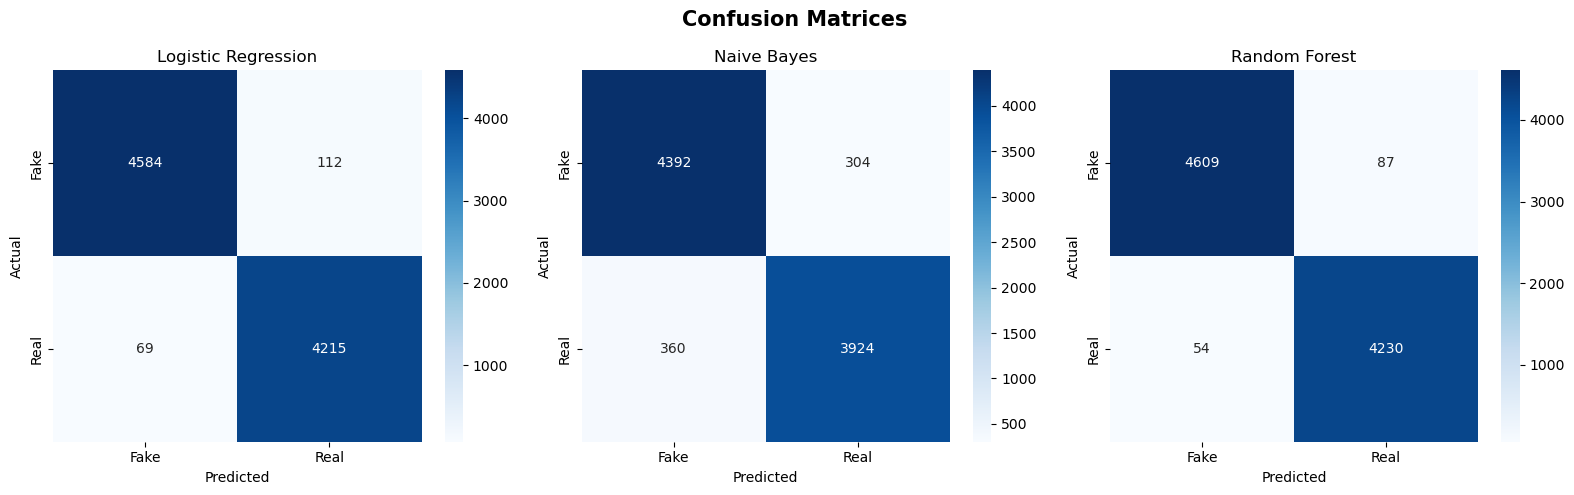

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

for ax, (name, model) in zip(axes, models.items()):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["Fake","Real"],
        yticklabels=["Fake","Real"]
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices", fontsize=15, fontweight="bold")

plt.tight_layout()
plt.show()

In [29]:
import joblib
joblib.dump(rf, "news_detector.pkl")
joblib.dump(tv, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']